## Import libraries

In [8]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

Storing the data in a dataframe

In [9]:
df = pd.read_parquet("DKHousingPrices.parquet")

In [10]:
print(df["date"].min(), "to", df["date"].max())
df.head()

1992-01-05 00:00:00 to 2024-10-26 00:00:00


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,2024-10-26,219,0,Villa,regular_sale,1974,4350000,0.0,5,215.0,20232.558594,Kildevangen 5,8382,Hinnerup,East & mid jutland,Jutland,3.1,NaN,NaN
1,2024-10-26,219,2,Summerhouse,regular_sale,1956,450000,0.0,3,36.0,12500.000000,Lykkestien 2,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
2,2024-10-26,219,1,Farm,regular_sale,1955,6600000,0.0,3,180.0,36666.667969,Sæderupvej 58,9260,Gistrup,North jutland,Jutland,3.1,NaN,NaN
3,2024-10-25,219,3,Apartment,family_sale,1945,1495000,0.0,2,64.0,23359.375000,"Tage-Hansens Gade 5, 1. tv",8000,Aarhus C,East & mid jutland,Jutland,3.1,NaN,NaN
4,2024-10-25,219,4,Villa,regular_sale,1967,3375000,0.0,5,176.0,19176.136719,Chr.Winthers Vej 5,8600,Silkeborg,East & mid jutland,Jutland,3.1,NaN,NaN


In [11]:
#Drop all rows with na in the sqm column
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


Quarter skal laves til en float istedet for datetime

In [12]:
# Example: Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")  # or .dt.to_timestamp().astype("int64")
df.head()


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


### Make dummy variables

In [13]:
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "nom_interest_rate%" ]])
y = df["purchase_price"]
X.shape, y.shape
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,house_type_Apartment,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,house_type_Villa,...,sales_type_other_sale,sales_type_regular_sale,area_Bornholm,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
1193,218,1971,3,78.0,3.35,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1194,218,2009,3,50.0,3.35,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
1195,218,1940,2,56.0,3.35,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1196,218,1950,4,72.0,3.35,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1197,218,1974,1,50.0,3.35,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False


Make the training and testing split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [15]:
# Create and fit the model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

In [16]:
#Evaluate the model
print("Score on training set: {:.3f}".format(simple_model.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(simple_model.score(X_test, y_test)))

Score on training set: 0.337
Score on test set: 0.336


In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Vælg hvilken kolonne vi vil forudsige
TARGET = "purchase_price"   # skift til "sqm_price" hvis I hellere vil forudsige pris per m2
assert TARGET in df.columns, f"Target '{TARGET}' findes ikke i df.columns"

In [35]:
# SAMPLE FOR DEVELOPMENT
data = df.copy()

print("Unique area examples:", df["area"].dropna().unique()[:20])
print("Counts per area (top 10):")
print(df["area"].value_counts().head(10))

# >>> FILTER KUN Capital og Copenhagen <<<
data = data[data["area"].isin(["Capital, Copenhagen"])].copy()

# Behold KUN de valgte kolonner
columns_to_keep = [
    "quarter",
    "house_type",
    "sales_type",
    "year_build",
    "purchase_price",
    "no_rooms",
    "sqm",
    "area",
    "nom_interest_rate%",
    "dk_ann_infl_rate%",
    "yield_on_mortgage_credit_bonds%",
    "city",
    "zip_code"
]

data = data[columns_to_keep].copy()

# Sørg for at vi har 'date' med til tids-split (kun til split, ikke nødvendigvis som feature)
if "date" not in data.columns and "date" in df.columns:
    data["date"] = df.loc[data.index, "date"]

data["date"] = pd.to_datetime(data["date"], errors="coerce")

# Tids-split: train = før 2024, case/test = 2024
train_df = data[data["date"].dt.year < 2024].copy()
test_2024_df = data[data["date"].dt.year == 2024].copy()

print("Train rows (<2024):", len(train_df))
print("Test rows (2024):", len(test_2024_df))

# >>> NYT: nummerér area hér <<<
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# nu er 'area' numerisk i data
data["zip_code"] = data["zip_code"].astype(str)






# Hvis quarter ikke allerede er numerisk
try:
    data["quarter"] = data["quarter"].astype("int64")
except:
    pass

# Definér target/feature matrice
# Definér target / features på train og 2024-test
y_train = train_df["purchase_price"].astype(float)
X_train = train_df.drop(columns=["purchase_price", "date"], errors="ignore")

y_test  = test_2024_df["purchase_price"].astype(float)
X_test  = test_2024_df.drop(columns=["purchase_price", "date"], errors="ignore")

# Fix: konverter bool-kolonner til 0/1
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_test[col]  = X_test[col].astype(int)

# Opdel featuretyper
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_features, categorical_features[:10]

Unique area examples: ['Capital, Copenhagen', 'Bornholm', 'North jutland', 'Fyn & islands', 'South jutland', 'Other islands', 'East & mid jutland', 'North Zealand']
Categories (8, object): ['Bornholm', 'Capital, Copenhagen', 'East & mid jutland', 'Fyn & islands', 'North Zealand', 'North jutland', 'Other islands', 'South jutland']
Counts per area (top 10):
area
South jutland          342248
Other islands          248024
East & mid jutland     247004
Capital, Copenhagen    237728
North jutland          166053
Fyn & islands          138425
North Zealand          111338
Bornholm                15893
Name: count, dtype: int64
Train rows (<2024): 227050
Test rows (2024): 10678


(['quarter',
  'year_build',
  'no_rooms',
  'sqm',
  'nom_interest_rate%',
  'dk_ann_infl_rate%',
  'yield_on_mortgage_credit_bonds%',
  'zip_code'],
 ['house_type', 'sales_type', 'area', 'city'])

In [29]:
df["area"].unique()[:50]

['Capital, Copenhagen', 'Bornholm', 'North jutland', 'Fyn & islands', 'South jutland', 'Other islands', 'East & mid jutland', 'North Zealand']
Categories (8, object): ['Bornholm', 'Capital, Copenhagen', 'East & mid jutland', 'Fyn & islands', 'North Zealand', 'North jutland', 'Other islands', 'South jutland']

In [30]:
# sørg for date er datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# filtrer kun rækker fra 2024
df_2024 = df[df["date"].dt.year == 2024]

# median pris
print(f"Median huspris i 2024: {df_2024['purchase_price'].mean():,.0f} kr.")

Median huspris i 2024: 2,564,056 kr.


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Numerisk pipeline: udfyld manglende værdier med median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

# Kategorisk pipeline: udfyld manglende værdier + one-hot
# max_categories/min_frequency begrænser antallet af dummy-kolonner (hvis din sklearn understøtter det)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False          # RandomForest vil gerne have dense; vær obs på RAM
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Random Forest – lidt lettere at træne, stadig god performance
rf = RandomForestRegressor(
    n_estimators=150,        # ned fra 500 → meget hurtigere
    max_depth=20,            # begrænser dybde → hurtigere, mindre overfitting
    min_samples_leaf=5,      # gør træerne lidt grovere → hurtigere, mere robust
    max_features="sqrt",     # færre features pr. split → hurtigere
    n_jobs=-1,
    random_state=42,
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf),
])

pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['quarter', 'year_build',
                                                   'no_rooms', 'sqm',
                                                   'nom_interest_rate%',
                                                   'dk_ann_infl_rate%',
                                                   'yield_on_mortgage_credit_bonds%',
                                                   'zip_code']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['house_type', 'sales_type',
                                                   'area', 'city'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       min_samples_leaf=5, n_estimators=150,
                                       n_jobs=-1, random_state=42))])

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Del data i træning og test
# Fix: konverter bool-kolonner til 0/1
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_test[col]  = X_test[col].astype(int)

# Træn modellen (FIT først)
pipe.fit(X_train, y_train)

# Forudsigelser
pred_train = pipe.predict(X_train)
pred_test  = pipe.predict(X_test)

r2_tr = r2_score(y_train, pred_train)
r2_te = r2_score(y_test, pred_test)
mae   = mean_absolute_error(y_test, pred_test)
rmse  = mean_squared_error(y_test, pred_test) ** 0.5

print(f"Train R^2: {r2_tr:.3f}")
print(f"Test  R^2: {r2_te:.3f}")
print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")

Train R^2: 0.805
Test  R^2: 0.567
MAE: 1,050,643
RMSE: 1,562,484


In [155]:
import pandas as pd
import numpy as np

# Funktion til at hente feature-navne efter preprocess (OneHotEncoder udvider dem)
def get_feature_names(column_transformer):
    output = []
    for name, trans, cols in column_transformer.transformers_:
        if name == "remainder":
            continue
        # find sidste step i subpipeline
        last_step = trans.named_steps[list(trans.named_steps.keys())[-1]]
        # hvis sidste step har metode til at hente navne (fx OneHotEncoder)
        if hasattr(last_step, "get_feature_names_out"):
            output.extend(last_step.get_feature_names_out(cols))
        else:
            output.extend(cols)
    return output

# få navne på features efter preprocessing pipeline
feat_names = get_feature_names(pipe.named_steps["preprocess"])
feat_importances = pipe.named_steps["model"].feature_importances_

# dataframe med importances
fi = pd.DataFrame({
    "feature": feat_names,
    "importance": feat_importances
}).sort_values(by="importance", ascending=False)

fi.head(20)  # vis top 20 vigtigste features

,feature,importance
18,"area_Capital, Copenhagen",0.129869
3,sqm,0.112650
6,yield_on_mortgage_credit_bonds%,0.087592
0,quarter,0.085918
2,no_rooms,0.055729
1,year_build,0.035714
4,nom_interest_rate%,0.035590
5,dk_ann_infl_rate%,0.027316
7,house_type_Apartment,0.026158
9,house_type_Summerhouse,0.022456


In [156]:
# Aggreger feature importance tilbage til den oprindelige kolonne
fi["base_feature"] = fi["feature"].str.split("_").str[0]
fi_grouped = fi.groupby("base_feature")["importance"].sum().sort_values(ascending=False)
fi_grouped.head(20)

base_feature
area       0.175236
city       0.150014
zip        0.128507
sqm        0.112650
house      0.090158
yield      0.087592
quarter    0.085918
no         0.055729
year       0.035714
nom        0.035590
dk         0.027316
sales      0.015576
Name: importance, dtype: float64

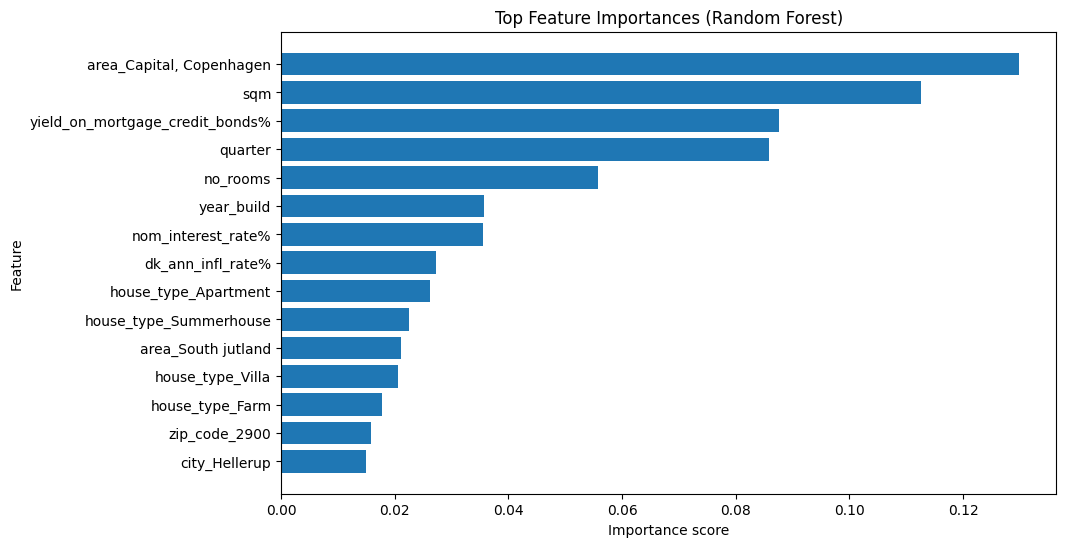

In [157]:
import matplotlib.pyplot as plt

top_n = 15  # vælg hvor mange features du vil vise

plt.figure(figsize=(10,6))
plt.barh(fi.head(top_n)["feature"], fi.head(top_n)["importance"])
plt.gca().invert_yaxis()  # vigtigste øverst
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.show()

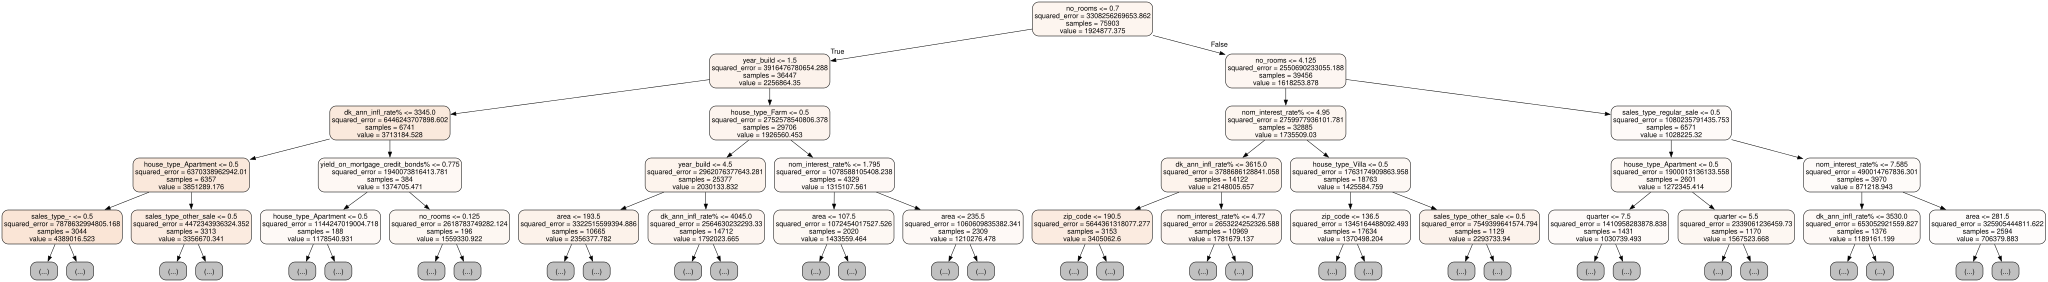

In [68]:
from sklearn.tree import export_graphviz
import graphviz

estimator = pipe.named_steps["model"].estimators_[0]  # tag træ nummer 0

dot_data = export_graphviz(
    estimator,
    out_file=None,
    feature_names=fi["feature"].tolist(),
    filled=True,
    rounded=True,
    max_depth=4  # begræns dybden så det er læsbart
)

graph = graphviz.Source(dot_data)
graph

**Clustering**

In [69]:
df_errors = X_test.copy()
df_errors["actual_price"] = y_test.values
df_errors["predicted_price"] = pred_test
df_errors["abs_error"] = np.abs(df_errors["actual_price"] - df_errors["predicted_price"])

df_errors.head()


df_errors["price_per_sqm"] = df_errors["actual_price"] / df_errors["sqm"]
df_errors = df_errors[df_errors["sqm"] > 20]

In [70]:
# Zip code skal være tal
df_errors["zip_code"] = df_errors["zip_code"].astype(int)

cluster_features = df_errors[[
    "abs_error",
    "sqm",
    "price_per_sqm",
    "zip_code"
]].copy()

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df_errors["cluster"] = clusters

In [72]:
#cluster-profiler
df_errors.groupby("cluster")[["abs_error", "sqm", "price_per_sqm"]].mean()


,abs_error,sqm,price_per_sqm
cluster,,,
0,5.401357e+05,144.960510,9930.752598
1,4.894311e+05,105.755966,20278.544491
2,3.385422e+06,147.253510,49248.464420


In [73]:
df_errors["cluster"].value_counts()

cluster
0    16056
1    12449
2     1495
Name: count, dtype: int64

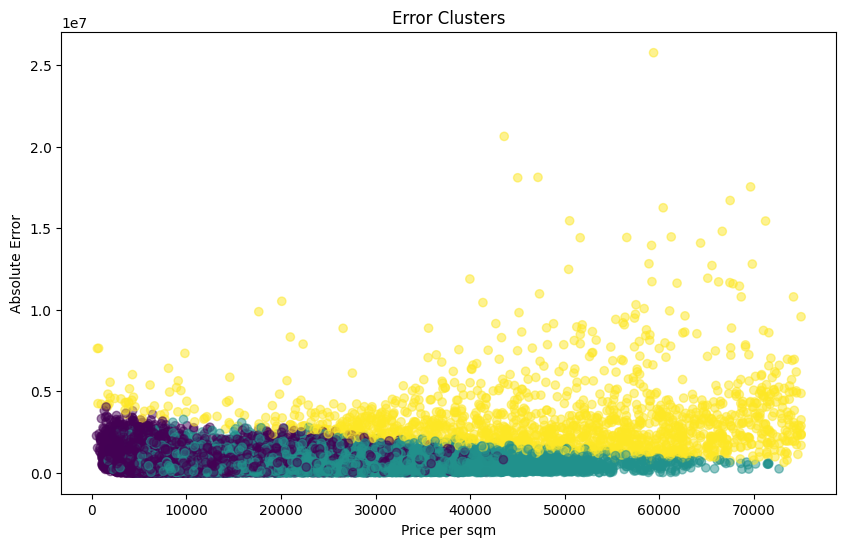

In [74]:
#Error vs price per sqm
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_errors["price_per_sqm"], df_errors["abs_error"],
            c=df_errors["cluster"], cmap="viridis", alpha=0.5)
plt.xlabel("Price per sqm")
plt.ylabel("Absolute Error")
plt.title("Error Clusters")
plt.show()

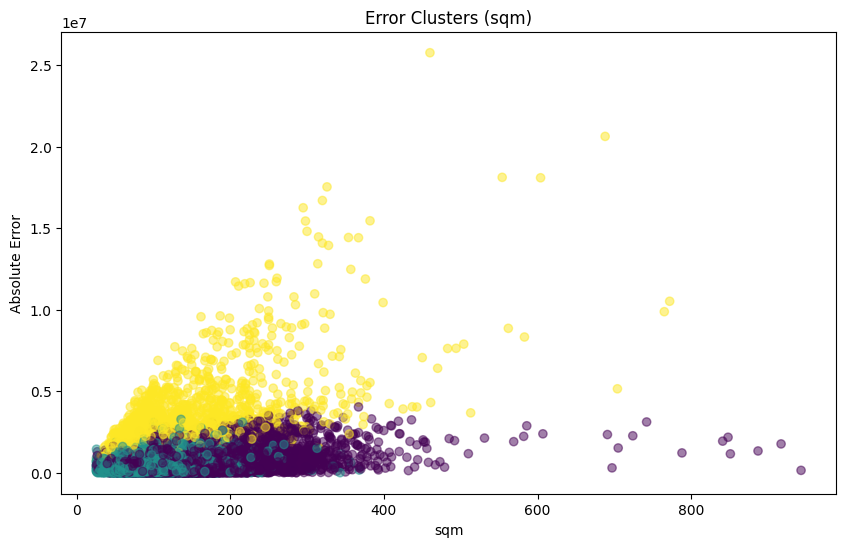

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(df_errors["sqm"], df_errors["abs_error"],
            c=df_errors["cluster"], cmap="viridis", alpha=0.5)
plt.xlabel("sqm")
plt.ylabel("Absolute Error")
plt.title("Error Clusters (sqm)")
plt.show()

In [37]:
# Fit modellen på <2024
pipe.fit(X_train, y_train)

print("Train rows:", len(X_train))
print("2024 rows:", len(X_test))

Train rows: 227050
2024 rows: 10678


In [39]:
# Vælg et tilfældigt hus fra 2024
case_house = test_2024_df.sample(1, random_state=42)

# X_case skal have samme kolonner som X_train/X_test (altså uden target + date)
X_case = case_house.drop(columns=["purchase_price", "date"], errors="ignore")

actual = case_house["purchase_price"].iloc[0]
pred   = pipe.predict(X_case)[0]

print("\nSingle 2024 house prediction:")
print(f"Actual:    {actual:,.0f} kr.")
print(f"Predicted: {pred:,.0f} kr.")
print(f"Error:     {pred-actual:,.0f} kr. ({(pred-actual)/actual*100:.2f}%)")


Single 2024 house prediction:
Actual:    3,475,000 kr.
Predicted: 3,100,691 kr.
Error:     -374,309 kr. (-10.77%)


In [98]:
# Sørg for modellen er trænet først
pipe.fit(X_train, y_train)

# Vælg ét tilfældigt hus fra 2024
case_house = test_2024_df.sample(1, random_state=42)  
# (fjern random_state hvis du vil have et nyt hus hver gang)

# Fjern target + date → kun features
X_case = case_house.drop(columns=["purchase_price", "date"], errors="ignore")

# Sand og forudsagt pris
actual = case_house["purchase_price"].iloc[0]
pred   = pipe.predict(X_case)[0]

print("\nSingle 2024 house prediction:")
print(f"Actual:    {actual:,.0f} kr.")
print(f"Predicted: {pred:,.0f} kr.")
print(f"Error:     {pred-actual:,.0f} kr. ({(pred-actual)/actual*100:.2f}%)")


Single 2024 house prediction:
Actual:    3,475,000 kr.
Predicted: 3,100,691 kr.
Error:     -374,309 kr. (-10.77%)


In [99]:
results = pd.DataFrame({
    "purchase_price": y_test.values,
    "predicted_price": pred_test
})

In [1]:
results = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": pred_test
})

# Procentvis fejl (positiv = overestimering, negativ = underestimering)
results["pct_error"] = (
    (results["predicted_price"] - results["actual_price"])
    / results["actual_price"]
) * 100

NameError: name 'pd' is not defined

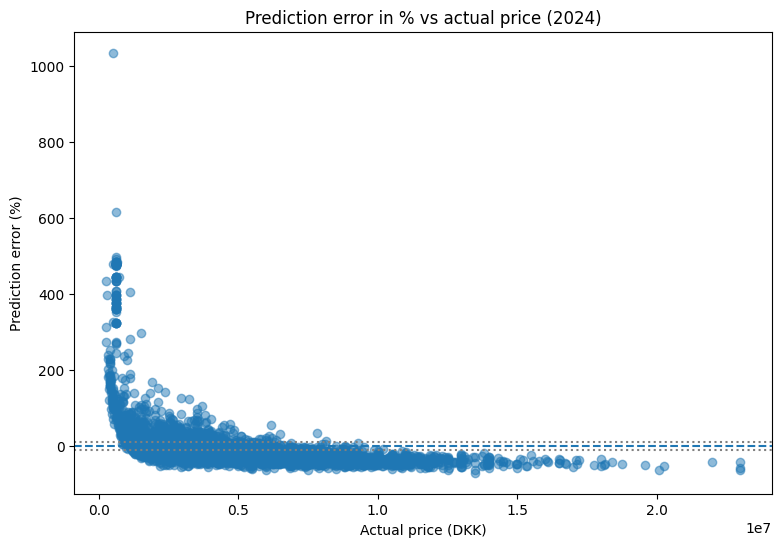

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.scatter(results["actual_price"], results["pct_error"], alpha=0.5)

plt.axhline(0, linestyle="--")   # perfekt prediction-linje
plt.axhline(10, linestyle=":", color="grey")
plt.axhline(-10, linestyle=":", color="grey")

plt.xlabel("Actual price (DKK)")
plt.ylabel("Prediction error (%)")
plt.title("Prediction error in % vs actual price (2024)")
plt.show()

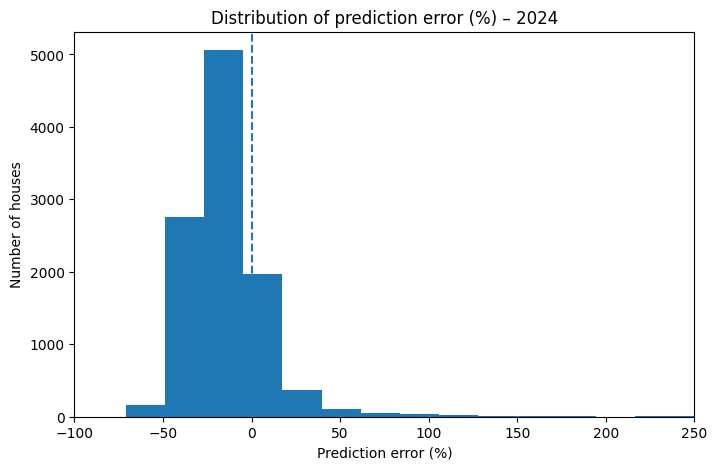

In [104]:
plt.figure(figsize=(8,5))
plt.hist(results["pct_error"], bins=50)

plt.axvline(0, linestyle="--")
plt.xlim(-100, 250)
plt.xlabel("Prediction error (%)")
plt.ylabel("Number of houses")
plt.title("Distribution of prediction error (%) – 2024")
plt.show()